In [1]:
from numpy import dtype
import boto3
import pandas as pd
import os  
from botocore.exceptions import NoCredentialsError
from dotenv import load_dotenv
import io
import numpy as np

In [2]:
load_dotenv()

True

## Camada Bronze criada em AWS S3

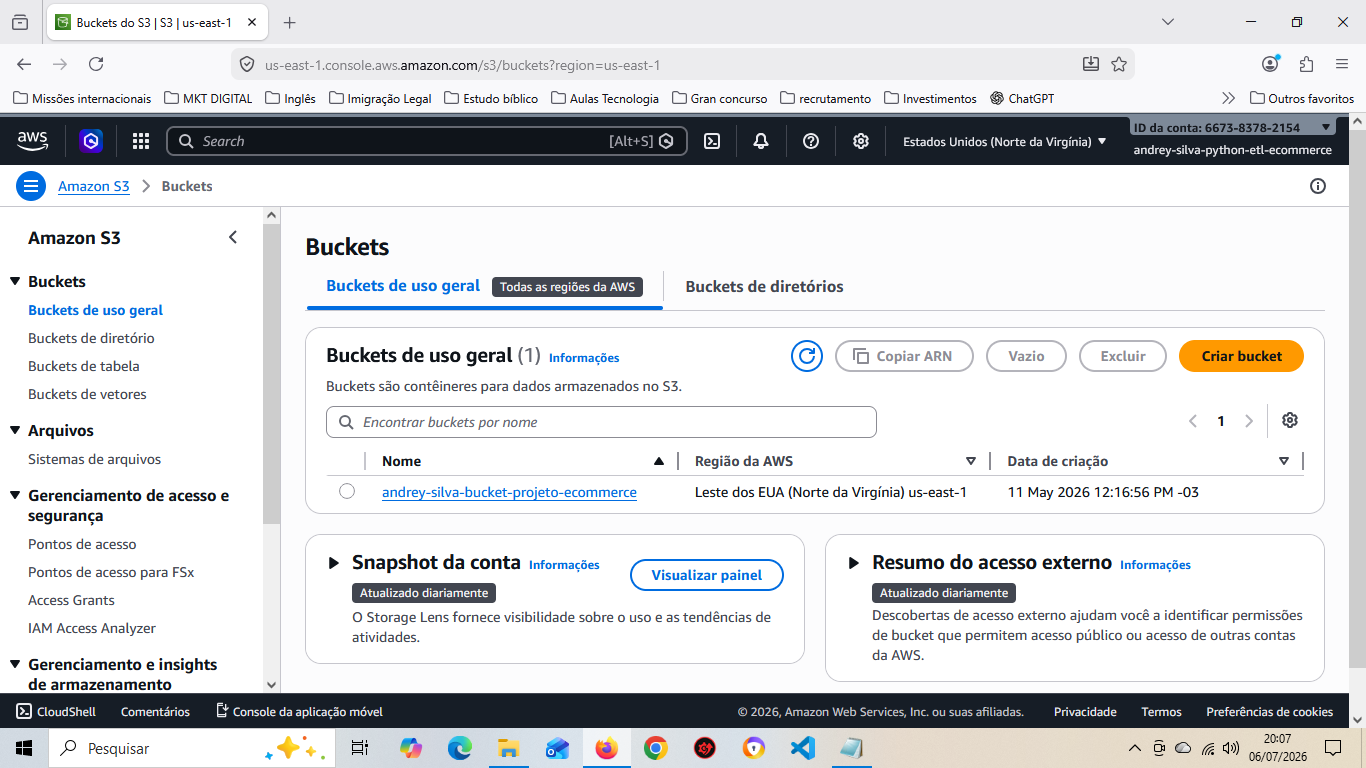

## Conectando ao DataLake AWS bucket S3

In [3]:
# conectar ao S3 da AWS usando dados do .env
s3_client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_ACCESS_KEY'),
    aws_secret_access_key=os.getenv('AWS_SECRET_KEY'),
    region_name='us-east-1'
    )

## ETL Tabela Dimensão geolocalizacao

In [4]:
#carregar tabela olist_geolocation_dataset do s3 para um dataframe do pandas
obj = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_geolocation_dataset.csv')
geolocalizacao = pd.read_csv(io.BytesIO(obj['Body'].read()))

In [5]:
#exibir as primeiras linhas do dataframe
geolocalizacao.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
# renomear colunas geolocalizacao
geolocalizacao.rename(columns={
    'geolocation_zip_code_prefix': 'cep_prefixo',
    'geolocation_lat': 'latitude',
    'geolocation_lng': 'longitude',
    'geolocation_city': 'cidade',
    'geolocation_state': 'estado'
}, inplace=True)

In [7]:
#mostrar colunas renomeadas
geolocalizacao.head()  

,cep_prefixo,latitude,longitude,cidade,estado
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [8]:
print(geolocalizacao['cidade'].unique())
print(geolocalizacao['estado'].unique())

<StringArray>
[            'sao paulo',             'são paulo', 'sao bernardo do campo',
               'jundiaí',       'taboão da serra',              'sãopaulo',
                    'sp',            'sa£o paulo',   'sao jose dos campos',
                'osasco',
 ...
       'ipiranga do sul',          'vila langaro',               'ciriaco',
      'floriano peixoto',              'erebango',                'ibiaçá',
  'santa cecilia do sul',               'ciríaco',               'estação',
          'vila lângaro']
Length: 8011, dtype: str
<StringArray>
['SP', 'RN', 'AC', 'RJ', 'ES', 'MG', 'BA', 'SE', 'PE', 'AL', 'PB', 'CE', 'PI',
 'MA', 'PA', 'AP', 'AM', 'RR', 'DF', 'GO', 'RO', 'TO', 'MT', 'MS', 'RS', 'PR',
 'SC']
Length: 27, dtype: str


In [9]:
# Normalizando texto para cidade e estado (remover acentos, caracteres especiais, etc.)
import unicodedata

def normalizar_texto(texto):
    if texto is None:
        return None
    # 1. Converte para minúsculas
    texto = texto.lower()
    # 2. Remove acentos (Normaliza NFD -> remove caracteres de marcação -> converte de volta para UTF-8)
    texto = unicodedata.normalize('NFD', texto)
    texto = "".join(c for c in texto if unicodedata.category(c) != 'Mn')
    # 3. Remove caracteres que não sejam letras ou espaços (limpeza de símbolos)
    import re
    texto = re.sub(r'[^\w\s]', '', texto)
    # 4. Remove espaços extras no início/fim
    return texto.strip()

# Aplicando na coluna cidade
geolocalizacao['cidade'] = geolocalizacao['cidade'].apply(normalizar_texto)

# Para o estado, geralmente basta deixar em maiúsculo e sem espaços
geolocalizacao['estado'] = geolocalizacao['estado'].str.upper().str.strip()

print(geolocalizacao['cidade'].unique()[:10])

<StringArray>
[            'sao paulo', 'sao bernardo do campo',               'jundiai',
       'taboao da serra',              'saopaulo',                    'sp',
   'sao jose dos campos',                'osasco',           'carapicuiba',
               'barueri']
Length: 10, dtype: str


In [10]:
# verificar tipo de dados em df_geolocalizacao_raw
print(geolocalizacao.dtypes)

cep_prefixo      int64
latitude       float64
longitude      float64
cidade             str
estado             str
dtype: object


In [11]:
# transformar colunas geolocation_lat e geolocation_lng para float
geolocalizacao['latitude'] = pd.to_numeric(geolocalizacao['latitude'], errors='coerce')
geolocalizacao['longitude'] = pd.to_numeric(geolocalizacao['longitude'], errors='coerce')

In [12]:
# transformar cep-prefixo em string para evitar problemas de formatação
geolocalizacao['cep_prefixo'] = geolocalizacao['cep_prefixo'].astype(str)

In [13]:
#verificar tipo de dados em geolocalizacao após transformação
print(geolocalizacao.dtypes)

cep_prefixo        str
latitude       float64
longitude      float64
cidade             str
estado             str
dtype: object


In [14]:
# verificar dados duplicados em df_geolocalizacao_raw
print(geolocalizacao.duplicated().sum())

279685


In [15]:
# deletar dados duplicados em geolocalizacao
geolocalizacao = geolocalizacao.drop_duplicates()

In [16]:
# verificar dos dados duplicados em df_geolocalizacao_raw
print(geolocalizacao.duplicated().sum())

0


In [17]:
# verificar dados nulos
print(geolocalizacao.isnull().sum())

cep_prefixo    0
latitude       0
longitude      0
cidade         0
estado         0
dtype: int64


In [18]:
#verificar linhas vazias
print(geolocalizacao[geolocalizacao.isnull().all(axis=1)].shape[0])

0


In [19]:
#tratamento cep_prefixo para não ter duplicidade na tabela, fazendo agrupamento
geolocalizacao = (
    geolocalizacao
    .groupby("cep_prefixo", as_index=False)
    .agg({
        "latitude": "mean",
        "longitude": "mean",
        "cidade": "first",
        "estado": "first"
    })
)

## ETL Tabela Dimensão Cliente

In [20]:
# carregando tabela olist_customers_dataset do s3 para um dataframe do pandas
obj_cliente = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_customers_dataset.csv')
clientes = pd.read_csv(io.BytesIO(obj_cliente['Body'].read()))


In [21]:
# exibir as primeiras linhas do dataframe
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [22]:
# renomear colunas clientes (cliente_id, cliente_unique_id, codigo_postal, cidade, estado)
clientes.rename(columns={'customer_id': 'cliente_id', 'customer_unique_id': 'cliente_unique_id', 'customer_zip_code_prefix': 'codigo_postal', 'customer_city': 'cidade', 'customer_state': 'estado'}, inplace=True)

In [23]:
clientes.head()

,cliente_id,cliente_unique_id,codigo_postal,cidade,estado
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [24]:
print(clientes['cidade'].unique())
print(clientes['estado'].unique())

<StringArray>
[               'franca', 'sao bernardo do campo',             'sao paulo',
       'mogi das cruzes',              'campinas',        'jaragua do sul',
               'timoteo',              'curitiba',        'belo horizonte',
         'montes claros',
 ...
              'balbinos',          'serra bonita',          'venda branca',
           'sanga puita',               'queiroz',                'siriji',
   'natividade da serra',          'monte bonito',            'sao rafael',
     'eugenio de castro']
Length: 4119, dtype: str
<StringArray>
['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA', 'MS', 'CE',
 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB', 'TO', 'PI', 'AC', 'SE',
 'RR']
Length: 27, dtype: str


In [25]:
# Normalizar texto para cidade e estado (remover acentos, caracteres especiais, etc.)
clientes['cidade'] = clientes['cidade'].apply(normalizar_texto) 
clientes['estado'] = clientes['estado'].apply(normalizar_texto)     

In [26]:
# verificar tipos de dados em clientes
print(clientes.dtypes)

cliente_id             str
cliente_unique_id      str
codigo_postal        int64
cidade                 str
estado                 str
dtype: object


In [27]:
# mudar tipo de dados de codigo_postal para string
clientes['codigo_postal'] = clientes['codigo_postal'].astype(str)

In [28]:
print(clientes.dtypes)

cliente_id           str
cliente_unique_id    str
codigo_postal        str
cidade               str
estado               str
dtype: object


In [29]:
# verificar dados duplicados em clientes
print(clientes.duplicated().sum())

0


In [30]:
# verificar dados nulos após tratamento
print(clientes.isnull().sum())

cliente_id           0
cliente_unique_id    0
codigo_postal        0
cidade               0
estado               0
dtype: int64


In [31]:
# verificar linhas vazias
print(clientes[clientes.isnull().all(axis=1)].shape[0])

0


## ETL Tabela Dimensão Vendedores

In [32]:
# carregar tabela olist_sellers_dataset do s3 para um dataframe do pandas
obj_vendedores = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_sellers_dataset.csv')
vendedores = pd.read_csv(io.BytesIO(obj_vendedores['Body'].read()))

In [33]:
# exibir as primeiras linhas do dataframe
vendedores.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [34]:
# renomear colunas vendedores (vendedor_id, codigo_postal_vendedores, cidade_vendedor, estado_vendedor)
vendedores.rename(columns={'seller_id': 'vendedor_id', 'seller_zip_code_prefix': 'codigo_postal_vendedores', 'seller_city': 'cidade_vendedor', 'seller_state': 'estado_vendedor'}, inplace=True)


In [35]:
# mostrar e excluir caracteres especiais e acentos em cidade_vendedor e estado_vendedor
vendedores['cidade_vendedor'] = vendedores['cidade_vendedor'].apply(normalizar_texto)
vendedores['estado_vendedor'] = vendedores['estado_vendedor'].apply(normalizar_texto)

In [36]:
# verificar tipos de dados em vendedores
print(vendedores.dtypes)

vendedor_id                   str
codigo_postal_vendedores    int64
cidade_vendedor               str
estado_vendedor               str
dtype: object


In [37]:
# mudar tipo de dados de codigo_postal para string
vendedores['codigo_postal_vendedores'] = vendedores['codigo_postal_vendedores'].astype(str)

In [38]:
# verificar duplicados em vendedores
vendedores.duplicated().sum()

np.int64(0)

In [39]:
# verificar dados nulos após tratamento
print(vendedores.isnull().sum())

vendedor_id                 0
codigo_postal_vendedores    0
cidade_vendedor             0
estado_vendedor             0
dtype: int64


In [40]:
# Verificar linhas vazias
print(vendedores[vendedores.isnull().all(axis=1)].shape[0])

0


## ETL Tab. Dimensão Produtos

In [41]:
# conectar a tabela olist_products_dataset.csv do s3 para um dataframe do pandas
obj_produtos = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_products_dataset.csv')

In [42]:
# exibir as primeiras linhas do dataframe
produtos = pd.read_csv(io.BytesIO(obj_produtos['Body'].read()))
produtos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [43]:
# renomear colunas produtos (produto_id, categoria_produto, nome_produto, marca_produto)
produtos.rename(columns={'product_id': 'produto_id', 'product_category_name': 'categoria_produto', 'product_name_lenght': 'tamanho_nome_produto', 'product_description_lenght': 'tamanho_descricao_produto', 'product_photos_qty': 'quantidade_fotos_produto', 'product_weight_g': 'peso_produto_g', 'product_length_cm': 'comprimento_produto_cm', 'product_height_cm': 'altura_produto_cm', 'product_width_cm': 'largura_produto_cm'}, inplace=True)

In [44]:
#exibir as primeiras linhas do dataframe renomeado
produtos.head()

,produto_id,categoria_produto,tamanho_nome_produto,tamanho_descricao_produto,quantidade_fotos_produto,peso_produto_g,comprimento_produto_cm,altura_produto_cm,largura_produto_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [45]:
# VERIFICAR TIPOS DE dados em produtos
print(produtos.dtypes)

produto_id                       str
categoria_produto                str
tamanho_nome_produto         float64
tamanho_descricao_produto    float64
quantidade_fotos_produto     float64
peso_produto_g               float64
comprimento_produto_cm       float64
altura_produto_cm            float64
largura_produto_cm           float64
dtype: object


In [46]:
# garantir que todos em categoria_produto sejam strings
produtos['categoria_produto'] = produtos['categoria_produto'].astype(str)

In [47]:
# verificar tipos de dados
print(produtos.dtypes)

produto_id                       str
categoria_produto                str
tamanho_nome_produto         float64
tamanho_descricao_produto    float64
quantidade_fotos_produto     float64
peso_produto_g               float64
comprimento_produto_cm       float64
altura_produto_cm            float64
largura_produto_cm           float64
dtype: object


In [48]:
# verificar dados nulos em produtos
print(produtos.isnull().sum())

produto_id                     0
categoria_produto            610
tamanho_nome_produto         610
tamanho_descricao_produto    610
quantidade_fotos_produto     610
peso_produto_g                 2
comprimento_produto_cm         2
altura_produto_cm              2
largura_produto_cm             2
dtype: int64


In [49]:
# listar somente o que está nas linhas com dados nulos
produtos[produtos.isnull().any(axis=1)]

,produto_id,categoria_produto,tamanho_nome_produto,tamanho_descricao_produto,quantidade_fotos_produto,peso_produto_g,comprimento_produto_cm,altura_produto_cm,largura_produto_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [50]:
# 1. Garantir que tudo na coluna categoria_produto é tratado como string para podermos limpar
produtos['categoria_produto'] = produtos['categoria_produto'].astype(str).str.strip()

In [51]:
# 2. Transformar textos falsos de "nan" em nulos reais do Python/Pandas
produtos['categoria_produto'] = produtos['categoria_produto'].replace(['nan', 'NaN', 'null', ''], np.nan)

In [52]:
# 3. substitui os nulos reais por "sem categoria" e salva na coluna
produtos['categoria_produto'] = produtos['categoria_produto'].fillna("sem categoria")

In [53]:
#verificar coluna categoria_produto após tratamento se existe NaN ou nulos
print(produtos['categoria_produto'].isnull().sum())

0


In [54]:
# trocar NaN da coluna tamanho_nome_produto, tamanho_descricao_produto, quantidade_fotos_produto, peso_produto_g, comprimento_produto_cm, altura_produto_cm, largura_produto_cm  por 0
for coluna in ['tamanho_nome_produto', 'tamanho_descricao_produto', 'quantidade_fotos_produto', 'peso_produto_g', 'comprimento_produto_cm', 'altura_produto_cm', 'largura_produto_cm']:
    if produtos[coluna].isnull().sum() > 0:
        produtos[coluna] = produtos[coluna].fillna(0)

In [55]:
# mostrar dados nulos em produtos após tratamento
print(produtos.isnull().sum())

produto_id                   0
categoria_produto            0
tamanho_nome_produto         0
tamanho_descricao_produto    0
quantidade_fotos_produto     0
peso_produto_g               0
comprimento_produto_cm       0
altura_produto_cm            0
largura_produto_cm           0
dtype: int64


In [56]:
# normalizar texto para categoria_produto (remover acentos, caracteres especiais, etc.)
produtos['categoria_produto'] = produtos['categoria_produto'].apply(normalizar_texto)

In [57]:
# verificar duplicados em produtos
print(produtos.duplicated().sum())

0


In [58]:
# verificar linhas vazias em produtos
print(produtos[produtos.isnull().all(axis=1)].shape[0])

0


## ETL Tabela Fato Pedidos

In [59]:
# conectar a tabela olist_orders_dataset.csv do s3 para um dataframe do pandas
obj_pedidos = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_orders_dataset.csv')

In [60]:
# 1. Armazene o conteúdo em uma variável primeiro
file_content = obj_pedidos['Body'].read()

In [61]:
# 2. Verifique se não está vazio antes de ler com o Pandas
if not file_content:
    print("⚠️ Alerta: O arquivo está completamente vazio no servidor!")
else:
    # 3. Se tiver dados, o Pandas lê sem problemas
    pedidos = pd.read_csv(io.BytesIO(file_content))
    print("Sucesso! Primeiras linhas:")
    print(pedidos.head())

Sucesso! Primeiras linhas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26

In [62]:
#renomear colunas pedidos (pedido_id, cliente_id, vendedor_id, data_pedido, data_aprovacao_pedido, data_entrega_prevista, data_entrega_real, status_pedido)
pedidos.rename(columns={'order_id': 'pedido_id', 'customer_id': 'cliente_id', 'seller_id': 'vendedor_id', 'order_purchase_timestamp': 'data_pedido', 'order_approved_at': 'data_aprovacao_pedido', 'order_delivered_carrier_date': 'data_entrega_prevista_transportadora', 'order_delivered_customer_date': 'data_entrega_real', 'order_status': 'status_pedido', 'order_estimated_delivery_date': 'data_entrega_prevista_loja'}, inplace=True)

In [63]:
# verificar tipos de dados em produtos após tratamento
print(pedidos.dtypes)

pedido_id                               str
cliente_id                              str
status_pedido                           str
data_pedido                             str
data_aprovacao_pedido                   str
data_entrega_prevista_transportadora    str
data_entrega_real                       str
data_entrega_prevista_loja              str
dtype: object


In [64]:
# mudar tipo de dados de data_pedido, data_aprovacao_pedido, data_entrega_prevista_transportadora, data_entrega_real, data_entrega_prevista_loja para datetime
pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'], errors='coerce')
pedidos['data_aprovacao_pedido'] = pd.to_datetime(pedidos['data_aprovacao_pedido'], errors='coerce')
pedidos['data_entrega_prevista_transportadora'] = pd.to_datetime(pedidos['data_entrega_prevista_transportadora'], errors='coerce')
pedidos['data_entrega_real'] = pd.to_datetime(pedidos['data_entrega_real'], errors='coerce')
pedidos['data_entrega_prevista_loja'] = pd.to_datetime(pedidos['data_entrega_prevista_loja'], errors='coerce')

In [65]:
# verificar tipos de dados em produtos após tratamento
print(pedidos.dtypes)

pedido_id                                          str
cliente_id                                         str
status_pedido                                      str
data_pedido                             datetime64[us]
data_aprovacao_pedido                   datetime64[us]
data_entrega_prevista_transportadora    datetime64[us]
data_entrega_real                       datetime64[us]
data_entrega_prevista_loja              datetime64[us]
dtype: object


In [66]:
# verificar dados duplicados em pedidos
print(pedidos.duplicated().sum())

0


In [67]:
# verificar dados nulos em pedidos
print(pedidos.isnull().sum())

pedido_id                                  0
cliente_id                                 0
status_pedido                              0
data_pedido                                0
data_aprovacao_pedido                    160
data_entrega_prevista_transportadora    1783
data_entrega_real                       2965
data_entrega_prevista_loja                 0
dtype: int64


### Legenda importante
#### Data de aprovação do produto se nulo = não pago ou cancelado
#### Previsão transportadora se nulo = não enviado ainda
#### Data entrega real se nulo = produto em trânsito

In [68]:
# verificar linhas vazias em pedidos
print(pedidos[pedidos.isnull().all(axis=1)].shape[0])

0


## ETL tabela fato Itens

In [69]:
# conectar a tabela olist_order_items_dataset.csv do s3 para um dataframe do pandas
obj_itens = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_order_items_dataset.csv')

In [70]:
# exibir as primeiras linhas do dataframe itens_pedido
itens_pedido = pd.read_csv(io.BytesIO(obj_itens['Body'].read()))
itens_pedido.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [71]:
# renomear colunas itens_pedido (pedido_id, quantidade_item, produto_id, vendedor_id, data_limite_de_envio, preco_item, frete_valor)
itens_pedido.rename(columns={'order_id': 'pedido_id', 'order_item_id': 'quantidade_item', 'product_id': 'produto_id', 'seller_id': 'vendedor_id', 'shipping_limit_date': 'data_limite_envio', 'price': 'preco', 'freight_value': 'frete'}, inplace=True)  

In [72]:
# exibir as primeiras linhas do dataframe renomeado
itens_pedido.head()

,pedido_id,quantidade_item,produto_id,vendedor_id,data_limite_envio,preco,frete
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [73]:
# verificar duplicados em itens_pedido
print(itens_pedido.duplicated().sum())

0


In [74]:
# verificar dados nulos em itens_pedido
print(itens_pedido.isnull().sum())

pedido_id            0
quantidade_item      0
produto_id           0
vendedor_id          0
data_limite_envio    0
preco                0
frete                0
dtype: int64


In [75]:
# verificar linhas vazias em itens_pedido
print(itens_pedido[itens_pedido.isnull().all(axis=1)].shape[0])

0


In [76]:
# verificar tipos de dados em itens_pedido
print(itens_pedido.dtypes)

pedido_id                str
quantidade_item        int64
produto_id               str
vendedor_id              str
data_limite_envio        str
preco                float64
frete                float64
dtype: object


In [77]:
# mudar tipo de dados de data_limite_envio para datetime
itens_pedido['data_limite_envio'] = pd.to_datetime(itens_pedido['data_limite_envio'], errors='coerce')
print(itens_pedido.dtypes)

pedido_id                       str
quantidade_item               int64
produto_id                      str
vendedor_id                     str
data_limite_envio    datetime64[us]
preco                       float64
frete                       float64
dtype: object


## ETL Tabela Fato Pagamento

In [78]:
# conectar a tabela olist_order_payments_dataset.csv do s3 para um dataframe do pandas
obj_pagamentos = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_order_payments_dataset.csv')

In [79]:
# exibir as primeiras linhas do dataframe pagamentos
pagamentos = pd.read_csv(io.BytesIO(obj_pagamentos['Body'].read()))
print(pagamentos.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [80]:
# renomear colunas pagamentos (pedido_id, tipo_pagamento, parcelas_pagamento, valor_pagamento)
pagamentos.rename(columns={'order_id': 'pedido_id', 'payment_sequential': 'sequencial_pagamento', 'payment_type': 'tipo_pagamento', 'payment_installments': 'parcelas', 'payment_value': 'valor_pagamento'}, inplace=True)
print(pagamentos.head())

                          pedido_id  sequencial_pagamento tipo_pagamento  \
0  b81ef226f3fe1789b1e8b2acac839d17                     1    credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                     1    credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                     1    credit_card   
3  ba78997921bbcdc1373bb41e913ab953                     1    credit_card   
4  42fdf880ba16b47b59251dd489d4441a                     1    credit_card   

   parcelas  valor_pagamento  
0         8            99.33  
1         1            24.39  
2         1            65.71  
3         8           107.78  
4         2           128.45  


In [81]:
# verificar tipo de dados em pagamentos
print(pagamentos.dtypes)

pedido_id                   str
sequencial_pagamento      int64
tipo_pagamento              str
parcelas                  int64
valor_pagamento         float64
dtype: object


In [82]:
# verificar na coluna tipo_pagamento quais são os tipos de pagamento disponíveis
print(pagamentos['tipo_pagamento'].unique())

<StringArray>
['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
Length: 5, dtype: str


In [83]:
# renomear tipos de pagamento disponíveis para português (boleto, cartão de crédito, cartão de débito, voucher, pagamento digital)
pagamentos['tipo_pagamento'] = pagamentos['tipo_pagamento'].replace({
    'boleto': 'Boleto',
    'credit_card': 'Credito',
    'debit_card': 'Debito',
    'voucher': 'Voucher',
    'not_defined': 'nao_definido'
})
print(pagamentos['tipo_pagamento'].unique())

<StringArray>
['Credito', 'Boleto', 'Voucher', 'Debito', 'nao_definido']
Length: 5, dtype: str


In [84]:
# normalizar texto para tipo_pagamento (remover acentos, caracteres especiais, etc.)
pagamentos['tipo_pagamento'] = pagamentos['tipo_pagamento'].apply(normalizar_texto)

In [85]:
# verificar dados duplicados em pagamentos
print(pagamentos.duplicated().sum())

0


In [86]:
# verificar dados nulos em pagamentos
print(pagamentos.isnull().sum())

pedido_id               0
sequencial_pagamento    0
tipo_pagamento          0
parcelas                0
valor_pagamento         0
dtype: int64


In [87]:
# verificar linhas vazias em pagamentos
print(pagamentos[pagamentos.isnull().all(axis=1)].shape[0])

0


## ETL Tabela Fato Avaliação

In [88]:
# Conectar a tabela olist_order_reviews_dataset.csv do s3 para um dataframe do pandas
obj_avaliacao = s3_client.get_object(Bucket='andrey-silva-bucket-projeto-ecommerce', Key='olist_order_reviews_dataset.csv')

In [89]:
# exibir as primeiras linhas do dataframe avaliacao
avaliacao = pd.read_csv(io.BytesIO(obj_avaliacao['Body'].read()))
print(avaliacao.head())

                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

In [90]:
# renomear as colunas de avaliacao (pedido_id, avaliacao_id, nota_avaliacao, titulo_avaliacao, descricao_avaliacao, data_avaliacao)
avaliacao.rename(columns={'review_id': 'avaliacao_id', 'order_id': 'pedido_id', 'review_score': 'nota_avaliacao', 'review_comment_title': 'titulo_avaliacao', 'review_comment_message': 'descricao_avaliacao', 'review_creation_date': 'data_criacao_avaliacao', 'review_answer_timestamp': 'data_resposta_avaliacao'}, inplace=True)

In [91]:
# verificar tipos de dados em avaliacao
print(avaliacao.dtypes)

avaliacao_id                 str
pedido_id                    str
nota_avaliacao             int64
titulo_avaliacao             str
descricao_avaliacao          str
data_criacao_avaliacao       str
data_resposta_avaliacao      str
dtype: object


In [92]:
# modificar tipo de dados de data_criacao_avaliacao e data_resposta_avaliacao para datetime
avaliacao['data_criacao_avaliacao'] = pd.to_datetime(avaliacao['data_criacao_avaliacao'], errors='coerce')
avaliacao['data_resposta_avaliacao'] = pd.to_datetime(avaliacao['data_resposta_avaliacao'], errors='coerce')
print(avaliacao.dtypes)

avaliacao_id                          str
pedido_id                             str
nota_avaliacao                      int64
titulo_avaliacao                      str
descricao_avaliacao                   str
data_criacao_avaliacao     datetime64[us]
data_resposta_avaliacao    datetime64[us]
dtype: object


In [93]:
# verificar dados duplicados em avaliacao
print(avaliacao.duplicated().sum())

0


In [94]:
# verificar dados nulos em avaliacao
print(avaliacao.isnull().sum())

avaliacao_id                   0
pedido_id                      0
nota_avaliacao                 0
titulo_avaliacao           87656
descricao_avaliacao        58247
data_criacao_avaliacao         0
data_resposta_avaliacao        0
dtype: int64


In [95]:
# exibir somente o que está nas linhas com dados nulos, somente nas colunas de interesse (titulo_avaliacao, descricao_avaliacao)
print(avaliacao[avaliacao.isnull().any(axis=1)][['titulo_avaliacao', 'descricao_avaliacao']])

      titulo_avaliacao                                descricao_avaliacao
0                  NaN                                                NaN
1                  NaN                                                NaN
2                  NaN                                                NaN
3                  NaN              Recebi bem antes do prazo estipulado.
4                  NaN  Parabéns lojas lannister adorei comprar pela I...
...                ...                                                ...
99219              NaN                                                NaN
99220              NaN                                                NaN
99221              NaN  Excelente mochila, entrega super rápida. Super...
99222              NaN                                                NaN
99223              NaN  meu produto chegou e ja tenho que devolver, po...

[89385 rows x 2 columns]


In [96]:
# trocar NaN da coluna titulo_avaliacao e descricao_avaliacao por "sem titulo" e "sem descricao"
avaliacao['titulo_avaliacao'] = avaliacao['titulo_avaliacao'].fillna("sem titulo")
avaliacao['descricao_avaliacao'] = avaliacao['descricao_avaliacao'].fillna("sem descricao")
print(avaliacao.isnull().sum())

avaliacao_id               0
pedido_id                  0
nota_avaliacao             0
titulo_avaliacao           0
descricao_avaliacao        0
data_criacao_avaliacao     0
data_resposta_avaliacao    0
dtype: int64


In [97]:
# normalizar colunas de texto (titulo_avaliacao, descricao_avaliacao) para remover acentos, caracteres especiais, etc.
avaliacao['titulo_avaliacao'] = avaliacao['titulo_avaliacao'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
avaliacao['descricao_avaliacao'] = avaliacao['descricao_avaliacao'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [98]:
# verificar dados normalizados em avaliacao
print(avaliacao.head())

                       avaliacao_id                         pedido_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   nota_avaliacao titulo_avaliacao  \
0               4       sem titulo   
1               5       sem titulo   
2               5       sem titulo   
3               5       sem titulo   
4               5       sem titulo   

                                 descricao_avaliacao data_criacao_avaliacao  \
0                                      sem descricao             2018-01-18   
1                                      sem descricao             2018-03-10   
2                                      sem descricao             2018-02-17   
3              R

In [99]:
# verificar linhas vazias em avaliacao
print(avaliacao[avaliacao.isnull().all(axis=1)].shape[0])

0


## Data warehouse criado no Postgre Servless usando Dbeaver.